In [1]:
# Suppress Warning messages
import warnings
warnings.simplefilter(action='ignore')

In [2]:
import pandas as pd
import sys
import os
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm

In [3]:
PROBLEM_NAME = 'Queens'

ALGORITHMS = [
    'RHC', 
    'SA', 
    'GA', 
    'MIMIC',
]

In [4]:
out_dir = f'learning_curves'
os.makedirs(out_dir, exist_ok=True)

In [5]:
df_dict = {}
for algorithm in ALGORITHMS:
    all_df = pd.read_csv(f'metrics/{PROBLEM_NAME}_100_{algorithm}/learning_curve.csv')
    # print(f"before: {len(all_df)}")
    all_df['Fitness'] = -1 * all_df['Fitness']
    best_run_num = all_df[all_df['Fitness'] == all_df['Fitness'].max()].iloc[0]['group_number']
    df = all_df[all_df['group_number'] == best_run_num]
    # print(f"{len(df)}")
    df_dict[algorithm] = df

In [6]:
if 'RHC' in df_dict:
    df = df_dict['RHC']
    for run_num in tqdm(df['run_number'].unique()):
        add_time = 0
        s_df = df[df['run_number'] == run_num]
        for restart in sorted(s_df['current_restart'].unique()):
            mask = np.logical_and(df['run_number'] == run_num, df['current_restart'] == restart)
            df.loc[mask, 'Time'] = df.loc[mask, 'Time'] + add_time
            add_time = df[mask]['Time'].max()

100%|██████████| 3/3 [00:00<00:00,  6.61it/s]


In [7]:
if 'RHC' in df_dict:
    df = df_dict['RHC']
    for run_num in tqdm(df['run_number'].unique()):
        best_fitness = None
        s_df = df[df['run_number'] == run_num]
        for i, row in s_df.iterrows():
            if best_fitness is None or row['Fitness'] > best_fitness:
                best_fitness = row['Fitness']
            df.loc[i, 'Fitness'] = best_fitness

100%|██████████| 3/3 [00:25<00:00,  8.66s/it]


In [8]:
data_dict = {}

max_time = all_df['Time'].max()
print(len(ALGORITHMS))
for alg, df in df_dict.items():
    print(f"Algorithm: {alg}")
    print(f"Iterations: {df['Iteration'].max()}")
    run_num = df['run_number'].unique()[0]
    run_df = df[df['run_number'] == run_num]
    print(len(run_df))
    for i, row in tqdm(run_df.iterrows()):
        s_df = df[df['Iteration'] == row['Iteration']]
        run_df.loc[i, 'fitness_mean'] = s_df['Fitness'].mean()
        run_df.loc[i, 'fitness_std'] = s_df['Fitness'].std()
    run_df = run_df.sort_values('Time')
    run_df = run_df.iloc[1:]
    X = np.array(run_df['Time'])
    y = np.array(run_df['fitness_mean'])
    y_error = np.array(run_df['fitness_std'])

    data_dict[alg] = (X, y, y_error)

4
Algorithm: RHC
Iterations: 987
51589


51589it [00:36, 1397.36it/s]


Algorithm: SA
Iterations: 4631
2465


2465it [00:01, 1662.86it/s]


Algorithm: GA
Iterations: 602
603


603it [00:00, 1683.36it/s]


Algorithm: MIMIC
Iterations: 114
103


103it [00:00, 1398.72it/s]


4


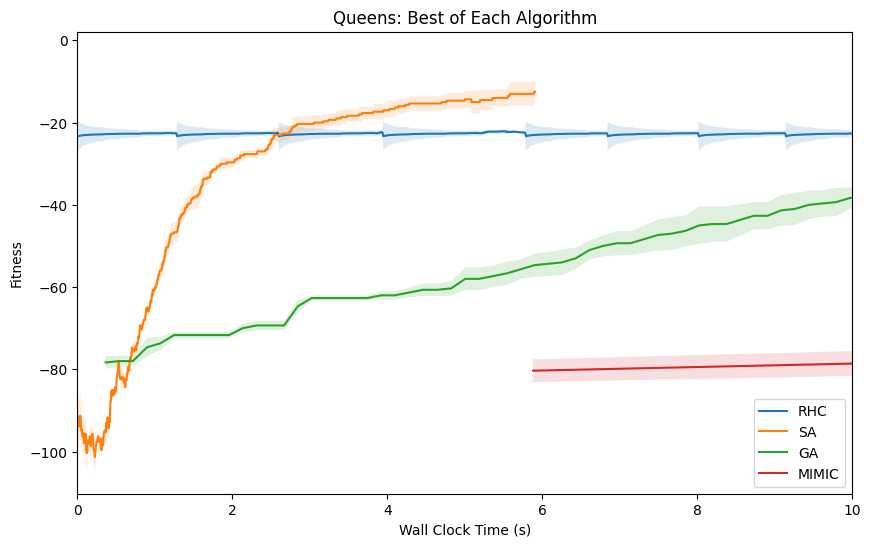

In [15]:
EXTEND = False
plt.figure(figsize=(10, 6))
max_time = all_df['Time'].max()
print(len(ALGORITHMS))
for alg, (X, y, y_error) in data_dict.items():
    if EXTEND:
        y = np.append(y, y[-1])
        X = np.append(X, max_time)
        y_error = np.append(y_error, y_error[-1])
    y_error = y_error / 2
    plt.plot(X, y, label=alg)
    plt.fill_between(X, y-y_error, y+y_error, alpha=0.15)
# set x limit to 200
plt.xlim(0, 10)
# set xlabel to Wall Clock Time (s) 
plt.xlabel('Wall Clock Time (s)')
plt.ylabel('Fitness')
# set legend position to bottom right
plt.legend(loc='lower right')
plt.title(f'{PROBLEM_NAME}: Best of Each Algorithm')

save_path = os.path.join(out_dir, f"{PROBLEM_NAME}_all_algorithms.png") 
plt.savefig(save_path)

In [12]:
df = df_dict['SA']
print(df['Temperature'].min(), df['Temperature'].max())
print(df['start_temperature'].unique())

10.0 10.0
[10.]


In [13]:
df = df_dict['SA']
print(df['Iteration'].min(), df['Iteration'].max())

0 4631
